# Synthetic Maser Data: Visualization and Initial Analysis

A worked example for developing and stress-testing our analysis on *simulated*
data before we look at the real maser labels. The findings are illustrative and
rest on arbitrary modelling choices; the goal is to stress-test and extend them
before anything is frozen into the pre-registration. The sections below explain
why we work this way and what synthetic data can tell us, then walk through the
analysis.

## Why this notebook exists

We have very few masers: roughly 53 positives in the X-ray sample and 114 in the
WISE sample. If we try lots of models and feature sets on the real labels and
then write up whatever scored best, we will almost certainly fool ourselves. With
this little signal, something will look good by luck. That is p-hacking, and it
is how a result that does not replicate ends up in a paper.

The point of this notebook is to let us hack freely **before** looking at the
real labels. We simulate data with known truth, develop the comparison machinery,
stress-test assumptions, and only then freeze the pre-registration. This is our
small version of a blind analysis.

There is precedent for this sort of thing in the astrophysics literature. 
Large survey teams use simulated sky survey data to
develop and validate analysis pipelines before applying them to real data[1]. In statistics, simulation
studies with known truth are a standard way to evaluate methods before trusting
them on data where the truth is unknown [2]. Here the idea is the same:
use real feature distributions, invent the labels, learn how the methods behave,
then unblind once.

## The main rule

**You may look at the real features. You may not tune choices on the real
labels.**

Looking at the distribution of L12, WISE colours, distance, and feature
correlations is allowed; those are the inputs the simulator uses. What is not
allowed is deciding that a model, feature set, threshold, or plotting choice is
good because it won on the real maser labels. Here, the label boundary is
invented by `scenario`, not inferred from real detections.

`synth_data.py` enforces this structurally: nothing here touches the real maser
labels. The generator draws from the real feature values only (the X-ray and
WISE columns) and invents the labels itself from the chosen scenario.

## What synthetic data can and cannot tell us

Synthetic data **can** answer engineering and statistical questions:

- How unstable are cross-validation scores at our sample size?
- If the truth contains an interaction of a given strength, can our test detect
  it?
- How badly do flexible models overfit?
- How do distance-limited non-detections distort observed labels? A galaxy can
  truly host a maser but be too far away or too shallowly observed for the survey
  to detect it. In the real catalog that object is recorded as a non-detection,
  even though it is not a true negative. The simulator lets us compare `z_true`
  (latent maser host) with the observed target label, so we can see whether a
  model is being unfairly penalized for ranking distant true masers highly.

Synthetic data **cannot** tell us which model the real astrophysics wants. The
truth is whatever we put in. A result only earns its way into the
pre-registration if it survives several plausible truths, feature samplers, and
signal strengths.

## What's in this notebook

- **Part 1** looks at the simulated datasets: how they are built, what the
  scenarios look like in the feature planes, and the true probability surface
  underneath the observed labels.
- **Part 2** walks through the baseline method comparisons: model vs model,
  the fitted boundary vs the paper's hand-drawn cuts, the WISE fusion question,
  overfitting, and operating-point noise.
- **Part 3** examines distance-driven label noise and the distance-cut remedy.

In [1]:
# Setup for Google Colab — no effect when running locally
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('maser-research'):
        !git clone https://github.com/spragunr/maser-research
    os.chdir('maser-research')

In [2]:
import sys, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
for p in ("src", "../src"):
    ap = os.path.abspath(p)
    if ap not in sys.path:
        sys.path.insert(0, ap)

import numpy as np
import matplotlib.pyplot as plt
import synth_data as sd
import synth_analysis as sa
from maser_data import FEATURES, TARGET
%matplotlib inline

## 1. The synthetic data

`make_dataset` returns a **pandas DataFrame whose columns are named exactly as in
the real data** (`maser_data.py`), so any pipeline you write here runs unchanged
on the real frames. It also carries two synthetic-only diagnostic columns,
`z_true` (the latent true label) and `detected`, which the real data cannot give
you.

### Main simulator knobs

**`make_dataset(plane, scenario, strength, feature_model, distance_noise)`** — 2-feature catalog on one plane:

- `plane`: `"xray"` uses `[L_12um_bestfit_1, Lob]`; `"wise"` uses `[w1w2, w2w3]`.
- `scenario`: `"linear"`, `"wedge"`, `"box"`, `"interaction"`, or `"blob"`.
- `strength`: larger values make the synthetic signal easier to detect.
- `feature_model`: `"bootstrap"` is the small-sample default; `"gmm"` is smoother for large-n effect-ceiling plots; `"gaussian"` is a deliberately simple sensitivity check.
- `distance_noise=True`: true masers can be recorded as non-detections when they are too distant.

**`make_fused_dataset(scenario, strength, wise_signal, feature_model, distance_noise)`** — 4-feature catalog combining X-ray and WISE columns:

- `wise_signal`: `0.0` means WISE colours are redundant with the X-ray features; larger values add independent information that only the fused model can access.
- All other knobs behave the same as above; `plane` is not an argument (the fused plane is always `[L_12um_bestfit_1, Lob, w1w2, w2w3]`).

The goal is not to find one synthetic setting where a favorite model wins; it is to find decisions that are stable across reasonable settings.

In [3]:
df = sd.make_dataset(plane="xray", scenario="wedge", seed=0)
print("columns:", list(df.columns))
print("synthetic dataset configuration:")
for key, value in df.attrs.items():
    if isinstance(value, (float, np.floating)):
        value = round(float(value), 4)
    print(f"  {key}: {value}")
df.head()

columns: ['L_12um_bestfit_1', 'Lob', 'is_megamaser_plus', 'Lum_dis', 'z_true', 'detected', 'p_true', 'p_obs']
synthetic dataset configuration:
  plane: xray
  scenario: wedge
  strength: 2.5
  feature_model: bootstrap
  jitter: 0.03
  signal_signs: (1.0, -1.0)
  distance_noise: False
  true_prevalence: 0.1139
  obs_prevalence: 0.1139


,L_12um_bestfit_1,Lob,is_megamaser_plus,Lum_dis,z_true,detected,p_true,p_obs
0,43.452325,42.058147,0,115.73,0,1,0.111001,0.111001
1,43.946954,41.226638,0,213.90,0,1,0.325619,0.325619
2,39.812201,39.691107,0,18.36,0,1,0.002327,0.002327
3,44.174294,43.924343,0,275.28,0,1,0.005964,0.005964
4,42.554714,42.303903,0,191.79,0,1,0.077252,0.077252


### Scenarios as pictures

The `scenario` argument sets the *true* decision boundary. Red = a maser
(observed target), grey = nonmaser. Positives sit in the **maser-rich corner**,
which the `signal_signs` orientation fixes a priori from the physics: for the
X-ray plane that is high `L_12um_bestfit_1` (mid-IR luminous) and low `Lob`
(X-ray faint, i.e. obscured), so the masers cluster toward the lower-right here.
`wedge`/`box` make a hard corner there, `interaction` tilts it, and `blob` makes
a central island. Feature positions come from a jittered bootstrap of the real
rows (the default `feature_model`: real feature rows resampled with a little
random jitter), so the cloud keeps the real skew and gaps.

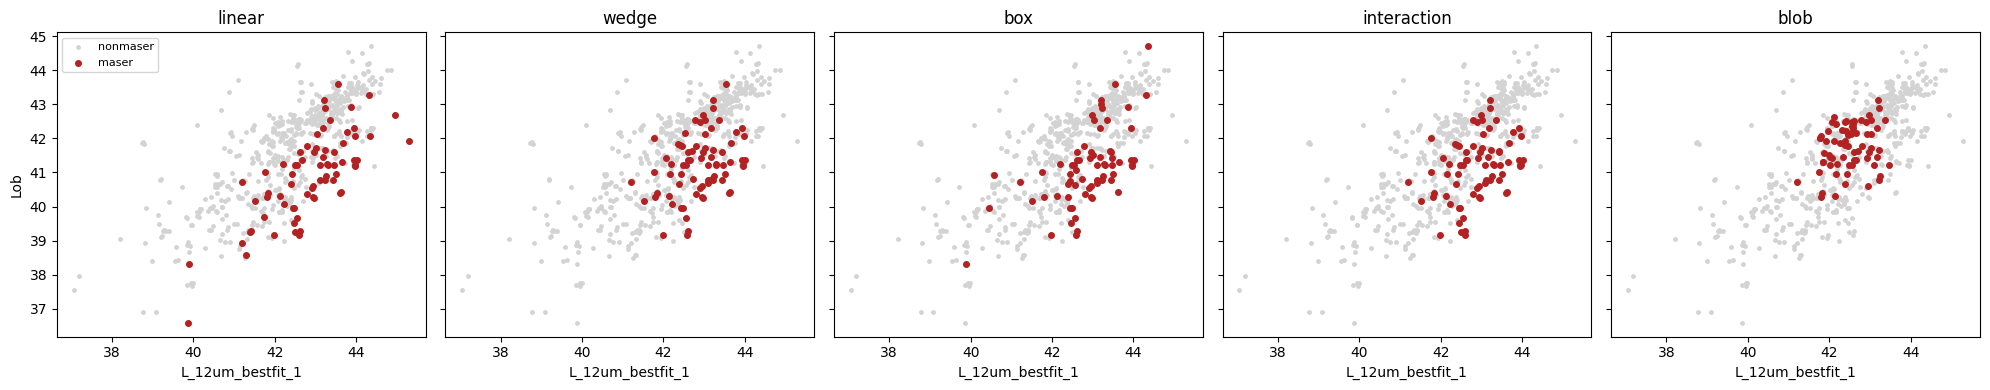

In [4]:
scenarios = ["linear", "wedge", "box", "interaction", "blob"]
xcol, ycol = FEATURES["xray"]
tgt = TARGET["xray"]

fig, axes = plt.subplots(1, len(scenarios), figsize=(20, 4),
                         sharex=True, sharey=True)
for ax, sc in zip(axes, scenarios):
    d = sd.make_dataset("xray", scenario=sc, strength=3.0, seed=0)
    neg, pos = d[d[tgt] == 0], d[d[tgt] == 1]
    ax.scatter(neg[xcol], neg[ycol], s=6, c="lightgray", label="nonmaser")
    ax.scatter(pos[xcol], pos[ycol], s=16, c="firebrick", label="maser")
    ax.set_title(sc)
    ax.set_xlabel(xcol)
axes[0].set_ylabel(ycol)
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### WISE scenarios as pictures

The WISE-only plane has its own two colours, `w1w2` and `w2w3`, and many more
positive examples than the X-ray sample (~114). The same synthetic scenarios are
available here. For WISE, the maser-rich corner is at high `w1w2` and high
`w2w3`, so wedge/box positives tend toward the upper-right.

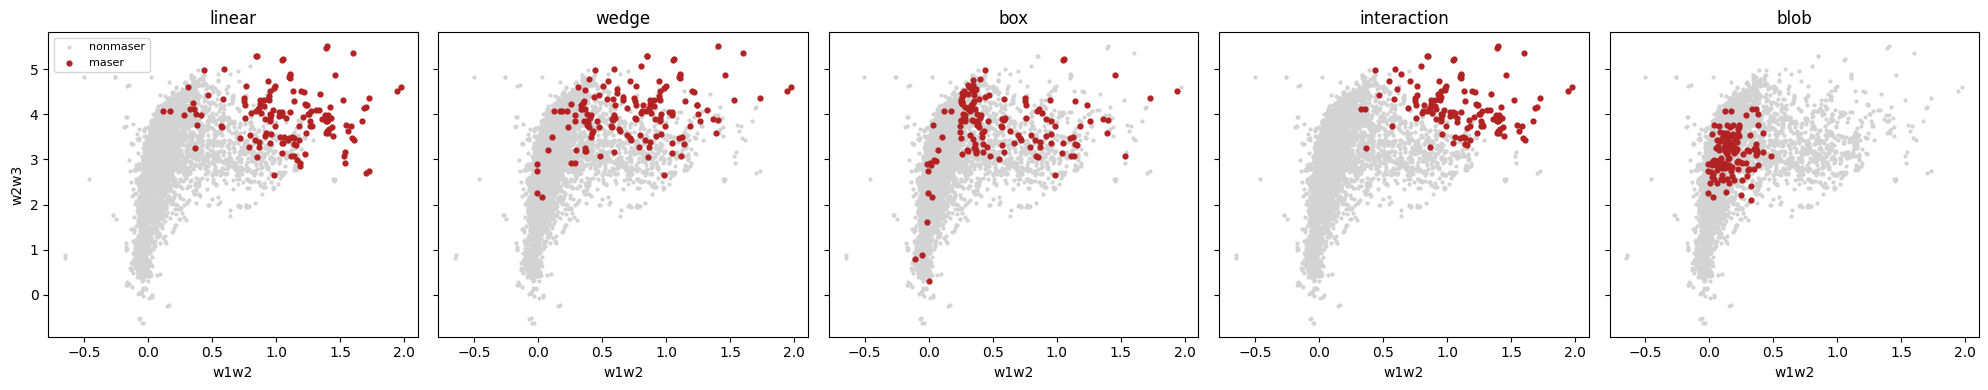

In [5]:
scenarios = ["linear", "wedge", "box", "interaction", "blob"]
wx, wy = FEATURES["wise"]
wt = TARGET["wise"]

fig, axes = plt.subplots(1, len(scenarios), figsize=(20, 4),
                         sharex=True, sharey=True)
for ax, sc in zip(axes, scenarios):
    d = sd.make_dataset("wise", scenario=sc, strength=3.0, seed=0)
    neg, pos = d[d[wt] == 0], d[d[wt] == 1]
    ax.scatter(neg[wx], neg[wy], s=4, c="lightgray", label="nonmaser")
    ax.scatter(pos[wx], pos[wy], s=12, c="firebrick", label="maser")
    ax.set_title(sc)
    ax.set_xlabel(wx)
axes[0].set_ylabel(wy)
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### The hidden probability surface

The scatter plots above show the *observed* labels: a galaxy is a maser or it
isn't. Underneath, each synthetic galaxy is generated by flipping a biased coin
whose probability the simulator sets exactly. Two synthetic-only columns expose
that probability (the real data has neither):

- **`p_true`** — the probability the galaxy is a *true* maser, `sigmoid(b0 + score)`.
- **`p_obs`** — the probability the *observed* label is 1, i.e. `p_true` times the
  chance a true maser was bright enough to be detected. With `distance_noise=False`
  the two are identical; section 3 below uses the gap between them to show what
  survey sensitivity does to the labels.

Shading below is `p_true`: the maser-likelihood surface a model must recover from
the dots alone. The points are the observed labels on top. Masers (red) cluster
where the surface is dark, but the coin is random, so a pale region still produces
the occasional red dot and a dark region produces many grey ones. That irreducible
noise, on top of only a few dozen positives, is why a single dataset can mislead.


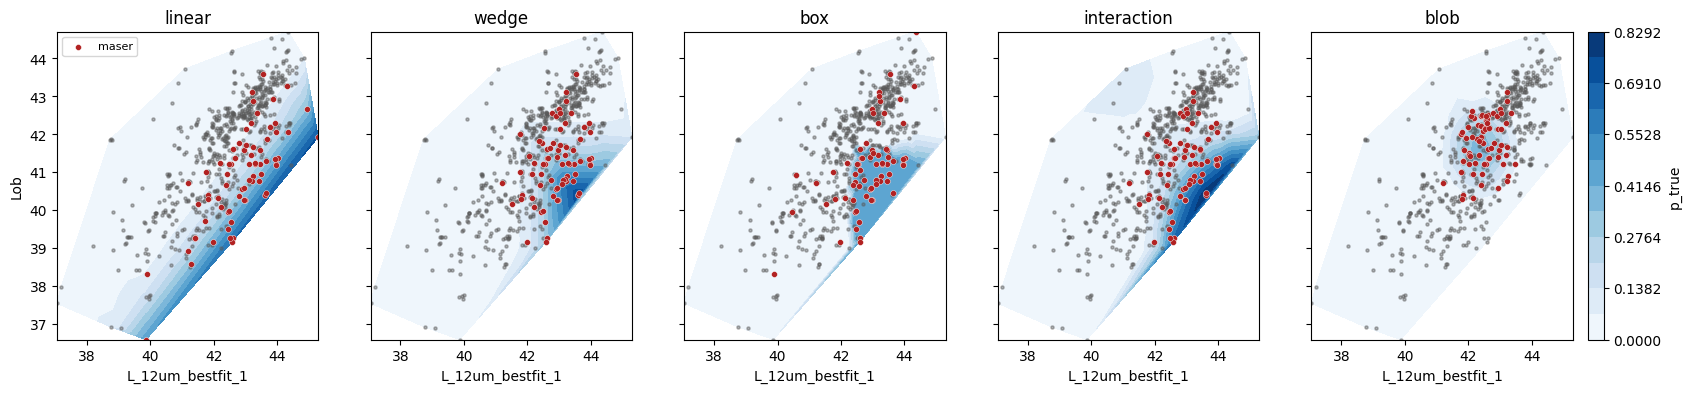

In [6]:
def plot_prob_contours(plane, neg_size, pos_size, scenarios=None):
    """Shade p_true (the true maser-likelihood surface) with observed labels on top."""
    scenarios = scenarios or ["linear", "wedge", "box", "interaction", "blob"]
    xcol, ycol = FEATURES[plane]
    tgt = TARGET[plane]
    data = [sd.make_dataset(plane, scenario=sc, strength=3.0, seed=0)
            for sc in scenarios]
    vmax = max(d["p_true"].max() for d in data)        # shared colour scale
    levels = np.linspace(0.0, vmax, 13)

    fig, axes = plt.subplots(1, len(scenarios), figsize=(20, 4),
                             sharex=True, sharey=True)
    for ax, sc, d in zip(axes, scenarios, data):
        cf = ax.tricontourf(d[xcol], d[ycol], d["p_true"], levels=levels,
                            cmap="Blues")
        neg, pos = d[d[tgt] == 0], d[d[tgt] == 1]
        ax.scatter(neg[xcol], neg[ycol], s=neg_size, c="0.35", alpha=0.45)
        ax.scatter(pos[xcol], pos[ycol], s=pos_size, c="firebrick",
                   edgecolor="white", linewidth=0.3, label="maser")
        ax.set_title(sc)
        ax.set_xlabel(xcol)
    axes[0].set_ylabel(ycol)
    axes[0].legend(loc="upper left", fontsize=8)
    fig.colorbar(cf, ax=axes, fraction=0.012, pad=0.01, label="p_true")
    plt.show()

plot_prob_contours("xray", neg_size=5, pos_size=18)


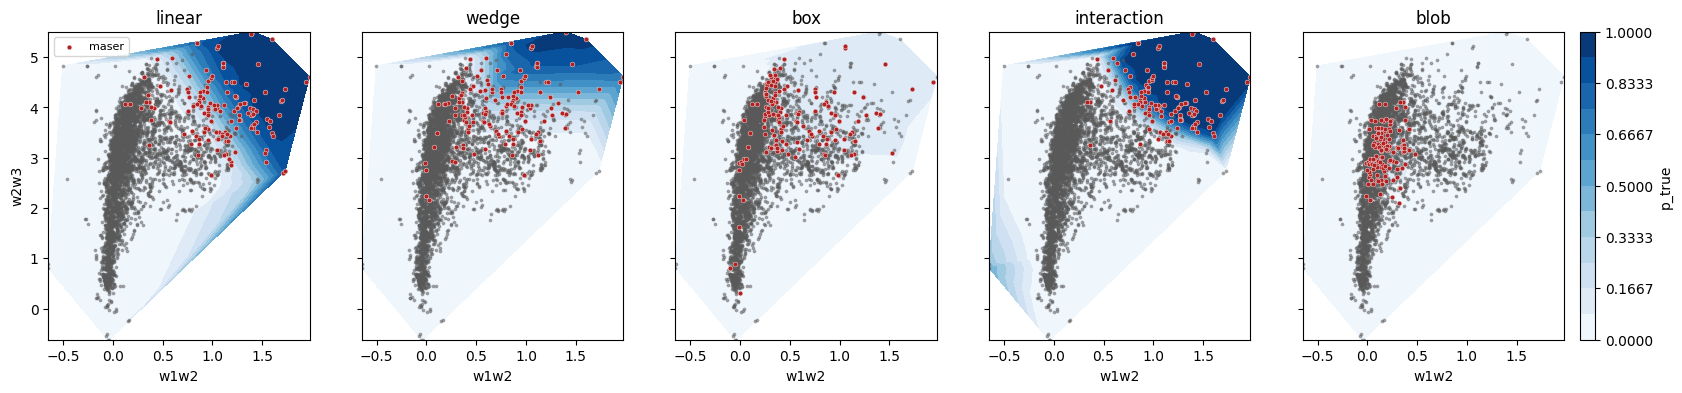

In [7]:
plot_prob_contours("wise", neg_size=3, pos_size=12)


## 2. Baseline analysis (illustrative)

Now we evaluate how the candidate models behave. Every number below depends on
the arbitrary truth we simulated, so treat each as a hypothesis to confirm or
break across several settings, not a fact.

### Is there anything to detect? (effect ceiling at large n)

Fit each candidate model and plain logistic regression on a huge sample so noise
disappears, and measure how much the candidate truly beats plain LR. If this
delta is ~0, no finite-sample test can find a difference, because there
genuinely is none. These large-n checks use the GMM feature sampler so the
synthetic cloud is smooth rather than many jittered copies of the empirical rows.

In [8]:
XF, XT = FEATURES["xray"], TARGET["xray"]
print("Large-n effect ceiling (test set n=40,000; feature_model='gmm')")
print("Values are delta AUC: candidate model AUC minus plain-LR AUC.")
print(f"{'scenario':12s} {'interaction_lr_delta_auc':>25s} {'quadratic_lr_delta_auc':>25s}")
for sc in ["linear", "wedge", "box", "interaction", "blob"]:
    big = sa.maker("xray", scenario=sc, n=40000, strength=3.0, feature_model="gmm")
    ci = sa.effect_ceiling(big, (sa.interaction_lr, XF), (sa.plain_lr, XF), XT)
    cq = sa.effect_ceiling(big, (sa.quadratic_lr, XF), (sa.plain_lr, XF), XT)
    print(f"{sc:12s} {ci['dAUC']:>+25.3f} {cq['dAUC']:>+25.3f}")

Large-n effect ceiling (test set n=40,000; feature_model='gmm')
Values are delta AUC: candidate model AUC minus plain-LR AUC.
scenario      interaction_lr_delta_auc    quadratic_lr_delta_auc


linear                          -0.000                    -0.000


wedge                           +0.088                    +0.091


box                             +0.038                    +0.038


interaction                     +0.084                    +0.084


blob                            +0.255                    +0.357


**Reading it:** with the smooth GMM feature cloud, `wedge` (~+0.08) and even
the hard `box` (~+0.03) give the interaction model a small but real edge at
infinite n; `interaction` and `blob` give more. How large these effects are
depends on the shape of the feature cloud, so compare against
`feature_model="bootstrap"` and `"gaussian"` before treating the pattern as
robust.

### Power: can we detect it at the real sample size?

Repeat the full cross-validated comparison over many simulated datasets and ask
how often the decision rule fires. Here `power_detected` means the fraction of
simulated datasets where the corrected CI excludes zero **and** the mean gain is
at least 2 extra masers in a full-sample top-50 campaign. The code below runs
this under several scenarios: `linear` (the truth is a straight line, so the
complex model has no real advantage) gives the false-positive rate, while
`wedge`, `box`, and `interaction` give the power under plausible true effects.

In [9]:
power_specs = [
    ("linear", sa.interaction_lr, "null -> false-positive rate"),
    ("wedge", sa.interaction_lr, "soft corner"),
    ("box", sa.interaction_lr, "hard corner"),
    ("interaction", sa.interaction_lr, "multiplicative interaction"),
    ("blob", sa.quadratic_lr, "central island (positive control)"),
]
for sc, build_a, note in power_specs:
    pw = sa.power_study(sa.maker("xray", scenario=sc, strength=3.0),
                        (build_a, XF), (sa.plain_lr, XF), XT, n_sims=30)
    print(f"truth={sc:12s} power_detected={pw['rate']:.2f}  "
          f"mean_extra_masers_top{pw['campaign']}={pw['mean_effect_masers']:+.2f}"
          f"  ({note})")

truth=linear       power_detected=0.00  mean_extra_masers_top50=-0.12  (null -> false-positive rate)


truth=wedge        power_detected=0.67  mean_extra_masers_top50=+4.37  (soft corner)


truth=box          power_detected=0.80  mean_extra_masers_top50=+4.19  (hard corner)


truth=interaction  power_detected=0.30  mean_extra_masers_top50=+3.23  (multiplicative interaction)


truth=blob         power_detected=1.00  mean_extra_masers_top50=+17.97  (central island (positive control))


**Reading it:** at the pre-registered operating point (+2 masers in a
full-sample top-50 campaign), the nonlinear comparisons have real power at n=641:
wedge ~0.7, box ~0.8, the explicit interaction ~0.4, and the blob positive
control ~1.0, while the linear null almost never fires. The effect is measured at
the full-sample campaign scale (top-50), not a per-fold top-10; those differ by
the number of folds, so be explicit about which scale a threshold refers to.

### Beating the hand-drawn cut (the headline comparison)

The paper selects candidates with fixed, hand-drawn cuts: Kuo's combined
inferred-N_H and L12 cut on the X-ray plane, and the Stern W1-W2 >= 0.8 colour
cut on WISE. These cuts are hard inside/outside rules, not probability scores.
For each held-out fold, we compute the cut's precision and recall, then evaluate
the fitted model at the same recall by choosing the model threshold with highest
precision subject to recall >= the cut's recall. Here the effect is converted to
extra masers at the cut's own selected-count operating point, not at top-50.

In [10]:
print("X-ray: fitted interaction-LR vs the Kuo N_H>=24 and L12>1e42 cut")
for sc in ["wedge", "box", "interaction"]:
    pw = sa.cut_power_study(sa.maker("xray", scenario=sc, strength=3.0),
                            (sa.interaction_lr, XF), (sa.xray_cut, XF), XT,
                            n_sims=30)
    print(f"  truth={sc:12s} power_detected={pw['rate']:.2f}  "
          f"mean_extra_masers_at_cut={pw['mean_effect_masers']:+.2f}  "
          f"mean_cut_selected={pw['mean_selected']:.1f} galaxies")

WF, WT = FEATURES["wise"], TARGET["wise"]
print("WISE: fitted interaction-LR vs the Stern W1-W2>=0.8 cut")
for sc in ["wedge", "interaction"]:
    pw = sa.cut_power_study(sa.maker("wise", scenario=sc, strength=3.0),
                            (sa.interaction_lr, WF), (sa.stern_cut, WF), WT,
                            n_sims=30)
    print(f"  truth={sc:12s} power_detected={pw['rate']:.2f}  "
          f"mean_extra_masers_at_cut={pw['mean_effect_masers']:+.2f}  "
          f"mean_cut_selected={pw['mean_selected']:.1f} galaxies")

X-ray: fitted interaction-LR vs the Kuo N_H>=24 and L12>1e42 cut


  truth=wedge        power_detected=0.83  mean_extra_masers_at_cut=+11.45  mean_cut_selected=91.9 galaxies


  truth=box          power_detected=0.83  mean_extra_masers_at_cut=+9.13  mean_cut_selected=91.9 galaxies


  truth=interaction  power_detected=0.63  mean_extra_masers_at_cut=+10.36  mean_cut_selected=91.9 galaxies
WISE: fitted interaction-LR vs the Stern W1-W2>=0.8 cut


  truth=wedge        power_detected=1.00  mean_extra_masers_at_cut=+103.28  mean_cut_selected=356.6 galaxies


  truth=interaction  power_detected=1.00  mean_extra_masers_at_cut=+188.65  mean_cut_selected=356.6 galaxies


**Reading it:** this checks whether the model-vs-cut comparison has power when
the synthetic truth is not exactly the paper's cut. The reported effect is the
precision gain converted into extra masers at the cut's own selected-count
operating point (`mean_cut_selected`), not at a fixed top-k budget. The real A1/C1 comparison
runs on the actual labels after the plan is frozen; this synthetic section only
checks whether the comparison machinery behaves sensibly.

**Why do the numbers look so large?** Two reasons.

First, and most important: the paper's cuts were chosen by looking at the real
maser labels, but the synthetic truth is our invented scenario — a wedge, box,
or interaction in the feature space, not the paper's cut. The fitted model adapts
to the actual synthetic boundary via cross-validation, while the paper cut is
optimized for something else entirely. On real data both are working from the
same underlying physics, which is a much fairer contest; here the fitted model
has a structural advantage.

Second, `strength=3.0` is a generous signal; real data may be weaker.

### Fusion: does adding WISE colours to X-ray help?

Same model (LR), two feature sets: the 4 fused columns vs the 2 X-ray columns.
`wise_signal=0` is a world where WISE is redundant; `wise_signal=1.5` is a world
where WISE carries real independent information.

In [11]:
for ws, label in [(0.0, "redundant WISE"), (1.5, "WISE adds signal")]:
    arm_a = (sa.plain_lr, FEATURES["fused"])
    arm_b = (sa.plain_lr, FEATURES["xray"])
    big = sa.fused_maker(scenario="linear", wise_signal=ws, n=40000,
                         strength=3.0, feature_model="gmm")
    ceil = sa.effect_ceiling(big, arm_a, arm_b, TARGET["fused"])
    pw = sa.power_study(sa.fused_maker(scenario="linear", wise_signal=ws,
                        strength=3.0), arm_a, arm_b, TARGET["fused"], n_sims=30)
    print(f"wise_signal={ws} ({label:16s}): "
          f"large_n_delta_auc={ceil['dAUC']:+.3f}  "
          f"power_detected_at_n602={pw['rate']:.2f}  "
          f"mean_extra_masers_top{pw['campaign']}={pw['mean_effect_masers']:+.2f}")

wise_signal=0.0 (redundant WISE  ): large_n_delta_auc=-0.000  power_detected_at_n602=0.00  mean_extra_masers_top50=-0.15


wise_signal=1.5 (WISE adds signal): large_n_delta_auc=+0.228  power_detected_at_n602=1.00  mean_extra_masers_top50=+24.12


**Reading it:** the fusion test behaves well: it correctly finds nothing
when WISE is redundant and detects the gain reliably when WISE adds real signal.
So "does WISE help?" is worth keeping as a confirmatory comparison.

### Optimism: a rough overfitting diagnostic

A flexible model can memorize its training data and score well on it without
having learned anything general — grading its own homework. Cross-validation
exposes this by scoring on held-out data the model never saw. The gap between
training AUC and cross-validated AUC is called *optimism*, and a large gap is a
warning sign for overfitting. It does not directly measure the two things we
actually care about (fold-to-fold variance of CV scores, and probability
calibration quality), but both deserve their own checks — see "Where to go
next." Logistic regression gets probability calibration for free from its
probabilistic formulation; tree models need a separate calibration step
(`CalibratedClassifierCV`) that consumes additional data.

In [12]:
print("Optimism = training/resubstitution AUC minus cross-validated AUC.")
mk = sa.maker("xray", scenario="interaction", strength=3.0)
for name, build in [("plain LR", sa.plain_lr), ("interaction LR", sa.interaction_lr),
                    ("random forest", sa.rf), ("boosted trees", sa.gbt)]:
    o = sa.optimism(build, mk, XF, XT, n_sims=10)
    print(f"{name:14s}: train_auc={o['resub_auc']:.3f}  "
          f"cv_auc={o['cv_auc']:.3f}  optimism_delta_auc={o['optimism']:+.3f}")

Optimism = training/resubstitution AUC minus cross-validated AUC.


plain LR      : train_auc=0.757  cv_auc=0.756  optimism_delta_auc=+0.001


interaction LR: train_auc=0.856  cv_auc=0.852  optimism_delta_auc=+0.005


random forest : train_auc=0.971  cv_auc=0.811  optimism_delta_auc=+0.159


boosted trees : train_auc=0.980  cv_auc=0.810  optimism_delta_auc=+0.171


**Reading it:** linear models barely overfit (optimism ~0.001–0.005); both tree
ensembles overfit heavily (~0.16–0.17). This is the practical argument for using
logistic regression as the primary model: trees are grading their own homework
so aggressively that their probability scores on new galaxies will be unreliable
without a separate calibration step. The RF-vs-boosting gap is negligible, so
this is not a reason to prefer one tree model over the other. The numbers depend
on the feature cloud, so check under `feature_model="gmm"` and `"gaussian"` before
treating the magnitude as definitive.

### Top-k noise: is "top-50" a stable operating point?

Across-fold spread of precision@k. Smaller k is noisier, so a too-small candidate
budget is dominated by which galaxies happened to land in which fold.

In [13]:
for k, v in sa.k_sensitivity(sa.plain_lr, mk, XF, XT).items():
    print(f"per_fold_precision_at_{k:<2d}: mean={v['mean']:.3f}  std_across_folds={v['std']:.3f}")

per_fold_precision_at_5 : mean=0.421  std_across_folds=0.211
per_fold_precision_at_10: mean=0.371  std_across_folds=0.140
per_fold_precision_at_20: mean=0.284  std_across_folds=0.078
per_fold_precision_at_50: mean=0.157  std_across_folds=0.036


**Reading it:** top-50 is a stable operating point — the std across folds is
small (~0.036) relative to the mean (~0.157). Top-5 and top-10 are much noisier
(std ~0.21 and ~0.14), meaning a campaign budget that small would be dominated by
the luck of which galaxies landed in which fold rather than by model quality.
The conclusion: pre-registering precision@10-per-fold (= top-50 full-sample) is
a reasonable choice; going much smaller would make the metric unreliable.

## 3. Label noise: when `maser = 0` means "not detected"

A non-detection is not always a true negative: a galaxy can host a maser that was
simply too faint to see at its distance. `distance_noise=True` reproduces this, a
true maser (`z_true=1`) beyond the sensitivity limit is recorded as `target=0`.
The black x's below are those false negatives, and they are the distant ones.

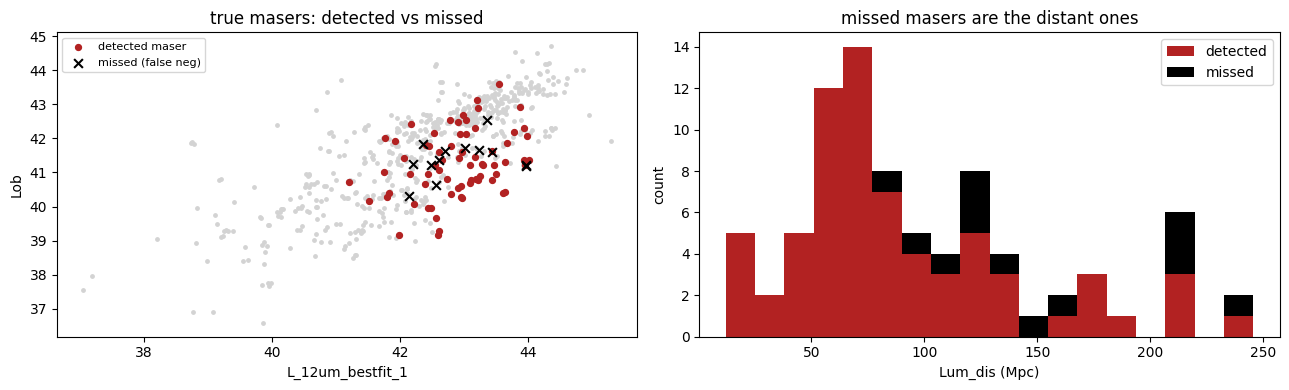

In [14]:
xcol, ycol = FEATURES["xray"]
d = sd.make_dataset("xray", scenario="wedge", strength=3.0,
                    distance_noise=True, seed=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

nm = d[d.z_true == 0]
seen = d[(d.z_true == 1) & (d.detected == 1)]
missed = d[(d.z_true == 1) & (d.detected == 0)]
ax[0].scatter(nm[xcol], nm[ycol], s=6, c="lightgray")
ax[0].scatter(seen[xcol], seen[ycol], s=18, c="firebrick", label="detected maser")
ax[0].scatter(missed[xcol], missed[ycol], s=40, c="black", marker="x",
              label="missed (false neg)")
ax[0].set_xlabel(xcol); ax[0].set_ylabel(ycol)
ax[0].set_title("true masers: detected vs missed")
ax[0].legend(fontsize=8)
ax[1].hist([seen["Lum_dis"], missed["Lum_dis"]], bins=18, stacked=True,
           color=["firebrick", "black"], label=["detected", "missed"])
ax[1].set_xlabel("Lum_dis (Mpc)"); ax[1].set_ylabel("count")
ax[1].set_title("missed masers are the distant ones")
ax[1].legend()
plt.tight_layout()
plt.show()

### Why it matters, and the fix

Rank the galaxies by the model and take the top 50. We can score that list three
ways: against the survey's observed labels (what you could actually compute on
real data), against the latent truth `z_true` (only possible in simulation), and
against the observed labels after a `Lum_dis < 170 Mpc` cut (the pre-registered
remedy).

In [15]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

def oof_topk(frame, eval_col, k=50):
    X = frame[FEATURES["xray"]].to_numpy()
    y = frame[TARGET["xray"]].to_numpy()
    p = cross_val_predict(sa.plain_lr(), X, y, method="predict_proba",
                          cv=StratifiedKFold(5, shuffle=True, random_state=0))[:, 1]
    top = np.argsort(p)[::-1][:k]
    return frame[eval_col].to_numpy()[top].mean()

clean, observed, truth, cut = [], [], [], []
for s in range(20):
    cl = sd.make_dataset("xray", "wedge", strength=3.0, seed=s)
    dn = sd.make_dataset("xray", "wedge", strength=3.0, distance_noise=True, seed=s)
    near = dn[dn["Lum_dis"] < 170].reset_index(drop=True)
    clean.append(oof_topk(cl, TARGET["xray"]))
    observed.append(oof_topk(dn, TARGET["xray"]))
    truth.append(oof_topk(dn, "z_true"))
    cut.append(oof_topk(near, TARGET["xray"]))

print("Mean precision@50 across 20 simulated datasets")
print(f"no_distance_noise_reference                 : {np.mean(clean):.3f}")
print(f"distance_noise_scored_vs_observed_labels    : {np.mean(observed):.3f}  <- what real data would show")
print(f"distance_noise_scored_vs_latent_true_labels : {np.mean(truth):.3f}  <- only knowable in simulation")
print(f"distance_noise_Dlt170_scored_vs_observed    : {np.mean(cut):.3f}  <- robustness remedy")

Mean precision@50 across 20 simulated datasets
no_distance_noise_reference                 : 0.333
distance_noise_scored_vs_observed_labels    : 0.290  <- what real data would show
distance_noise_scored_vs_latent_true_labels : 0.360  <- only knowable in simulation
distance_noise_Dlt170_scored_vs_observed    : 0.336  <- robustness remedy


**Reading it:** scored against the survey's labels on the full sample,
precision@50 looks worse (~0.29) than with no distance noise (~0.33). The model
has not gotten worse: scored against the latent truth it is actually ~0.36,
because it keeps ranking distant real masers highly from their features even
though the survey recorded them as non-detections. Those are exactly the
prospective candidates worth re-observing. Restricting to the well-searched
`Lum_dis < 170` subsample, where the labels are trustworthy, recovers an honest
~0.34. That is why we report results with a distance cut; it is the concrete form
of the pre-registration's D<170 robustness check.

## Where to go next

These baseline results depend on the simulator assumptions. Before any of them
is written into the frozen pre-registration, chase these checks:

1. **Feature samplers:** compare `feature_model="bootstrap"`, `"gmm"`, and
   `"gaussian"`.
2. **Boundary shape:** try sharper or softer corners, non-monotone boundaries,
   and different scenarios.
3. **Strength sweeps:** vary `strength` and `wise_signal` instead of trusting one
   point estimate.
4. **WISE plane:** repeat the power and ceiling studies with `plane="wise"`.
5. **Distance noise:** turn on `distance_noise` for every comparison that could
   be sensitive to false negatives.
6. **Operating point:** use `k_sensitivity` to check whether top-50 is stable.
7. **Fold-to-fold variance:** measure the std of per-fold CV scores across
   repeated splits, not just the mean, to see how much the score wobbles at this
   sample size.
8. **Calibration:** add a reliability diagram or Brier score check for models
   whose probability outputs will be used directly (not just for ranking).

A conclusion that holds across settings is safe to commit; one that wobbles is
itself the finding.

The real labels are used once, after the plan is frozen.

## References

[1] LSST Dark Energy Science Collaboration, Abolfathi, B., et al. (2021). The LSST
  DESC DC2 Simulated Sky Survey. *The Astrophysical Journal Supplement Series*,
  253, 31. A simulated sky built to develop and validate survey analysis
  pipelines before real data.
[2] Morris, T. P., White, I. R., & Crowther, M. J. (2019). Using simulation
  studies to evaluate statistical methods. *Statistics in Medicine*, 38,
  2074-2102. A practical guide to designing simulation studies for method
  evaluation.